Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


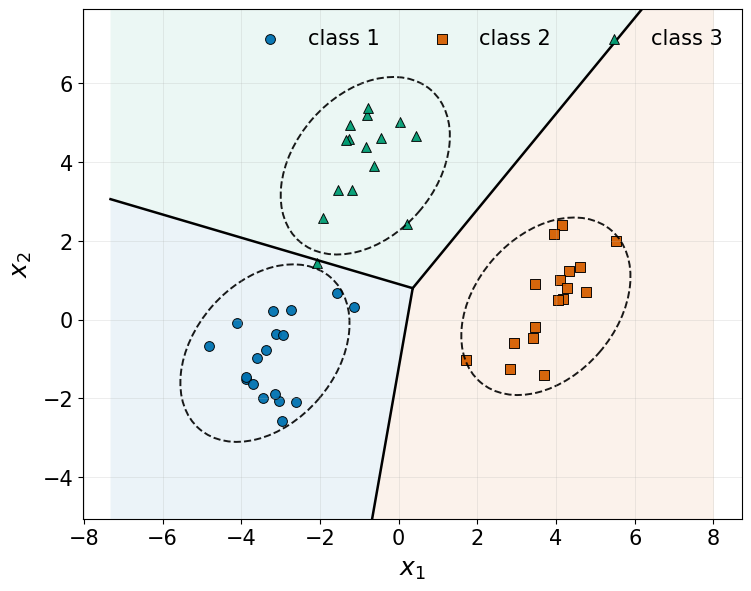

In [1]:
# LDA: 3 classes — dashed ellipses, faint regions, clipped decision boundaries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

rng = np.random.default_rng(7)

# ----- controls -----
C, n, separation = 3, 50, 1.7

# Okabe–Ito color-blind–friendly palette
OKABE_ITO = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#56B4E9",
             "#E69F00", "#000000", "#F0E442"]
colors  = OKABE_ITO[:C]
markers = ["o", "s", "^"]

# ----- LDA generative parameters -----
pi = np.repeat(1.0/C, C)
base_mus = np.array([[-2.0, -0.5],
                     [ 2.2,  0.2],
                     [-0.5,  2.3]], dtype=float)
mus = base_mus * separation
Sigma = np.array([[1.0, 0.35],
                  [0.35, 1.1]])
Sigma_inv = np.linalg.inv(Sigma)

# sample
ys = rng.choice(C, size=n, p=pi)
X  = np.vstack([rng.multivariate_normal(mus[c], Sigma) for c in ys])

# δ_c(x) = w_c^T x + b_c
w = (Sigma_inv @ mus.T).T
b = -0.5 * np.sum(mus @ Sigma_inv * mus, axis=1) + np.log(pi)

# pairwise boundary: (w_i - w_j)^T x + (b_i - b_j) = 0
def line_normal_and_offset(i, j):
    return w[i] - w[j], b[i] - b[j]

# intersection of two lines n1^T x + c1 = 0, n2^T x + c2 = 0
def intersect(n1, c1, n2, c2):
    A = np.vstack([n1, n2])
    Cvec = -np.array([c1, c2])
    return np.linalg.solve(A, Cvec)

# common intersection
n01, c01 = line_normal_and_offset(0, 1)
n02, c02 = line_normal_and_offset(0, 2)
P = intersect(n01, c01, n02, c02)

# plotting bounds
pad = 2.5
xmin, xmax = X[:,0].min()-pad, X[:,0].max()+pad
ymin, ymax = X[:,1].min()-pad, X[:,1].max()+pad

# faint decision regions
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 400),
                     np.linspace(ymin, ymax, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
g = grid @ w.T + b
pred = g.argmax(axis=1).reshape(xx.shape)

def cov_ellipse(mean, cov, k=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    width, height = 2 * k * np.sqrt(vals)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    return Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)

def ray_extent_from_point(P, d, xlim, ylim):
    ts = []
    if abs(d[0]) > 1e-12:
        ts += [(xlim[0]-P[0])/d[0], (xlim[1]-P[0])/d[0]]
    if abs(d[1]) > 1e-12:
        ts += [(ylim[0]-P[1])/d[1], (ylim[1]-P[1])/d[1]]
    ts_pos = [t for t in ts if t > 0]
    return 0.0 if not ts_pos else min(ts_pos)

# ---- figure ----
plt.rcParams.update({
    "font.size": 16,          # base font
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "legend.fontsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

fig, ax = plt.subplots(figsize=(7.4, 5.8), constrained_layout=True)

# faint regions
region_cmap = plt.matplotlib.colors.ListedColormap(colors)
ax.contourf(xx, yy, pred, levels=np.arange(C+1)-0.5,
            cmap=region_cmap, alpha=0.08, antialiased=True)

# samples
for c in range(C):
    idx = (ys == c)
    ax.scatter(X[idx, 0], X[idx, 1],
               s=50, c=colors[c], marker=markers[c],
               edgecolors="black", linewidths=0.7, alpha=0.95,
               label=f"class {c+1}")  # start from 1

# dashed ellipses
for c in range(C):
    ax.add_patch(cov_ellipse(mus[c], Sigma, k=2.15,
                             edgecolor="black", facecolor="none",
                             lw=1.4, alpha=0.9, linestyle="--"))

# decision boundaries as clipped half-lines
pairs = [(0,1), (0,2), (1,2)]
for (i, j) in pairs:
    no, c = line_normal_and_offset(i, j)
    d = np.array([-no[1], no[0]], dtype=float)
    d /= np.linalg.norm(d) + 1e-12
    k = ({0,1,2} - {i,j}).pop()
    if (w[k]-w[i]) @ d > 0 or (w[k]-w[j]) @ d > 0:
        d = -d
    tmax = ray_extent_from_point(P, d, (xmin, xmax), (ymin, ymax))
    Q = P + tmax * d
    ax.plot([P[0], Q[0]], [P[1], Q[1]], color="black", linewidth=1.8)

# aesthetics
ax.set_xlabel("$x_1$", labelpad=6)
ax.set_ylabel("$x_2$", labelpad=6)
ax.legend(frameon=False, ncol=3, loc="upper right")
ax.axis("equal")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.grid(True, linewidth=0.4, alpha=0.4)
plt.savefig('sample.png', dpi=600)

step  500 | nll=3.8393
step 1000 | nll=3.8393
step 1500 | nll=3.8393
step 2000 | nll=3.8393


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


step 2500 | nll=3.8393
--- Parameter comparison: gradient ML vs. closed-form MLE ---
||Δπ||_1   = 2.9802322387695312e-08
||Δμ||_F   = 0.00044810639797807615
||ΔΣ||_F   = 0.00029409350177942947


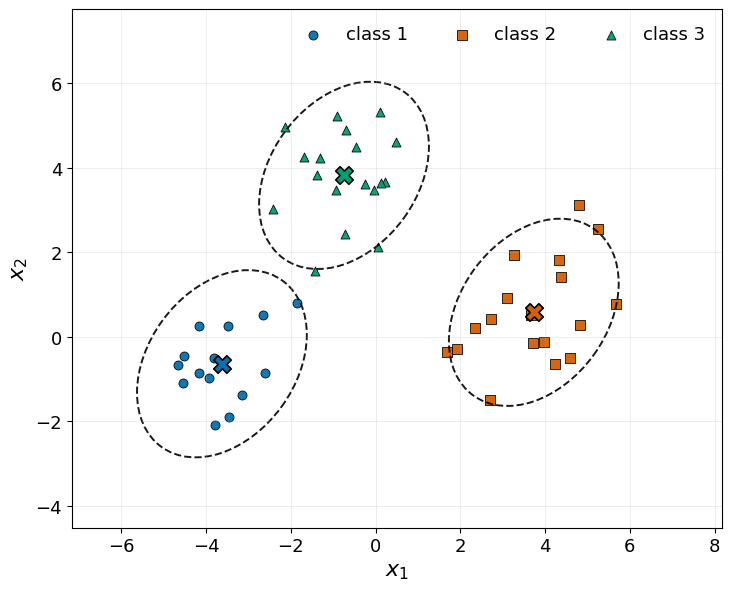

In [2]:
# Figure 2 — Gradient-based ML for classical LDA (n = 50)
# Shows optimizer (Adam) recovers the closed-form MLE.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import torch
import torch.nn.functional as F

rng = np.random.default_rng(0)

# ----------------------------
# 1) Synthetic LDA data (d=2, C=3)
#    Use the parameters defined in the first cell.
# ----------------------------
C = pi.shape[0]
d = mus.shape[1]

pi_true = pi
mus_true = mus
Sigma_true = Sigma

ys = rng.choice(C, size=n, p=pi_true)
X  = np.vstack([rng.multivariate_normal(mus_true[c], Sigma_true) for c in ys])

# ----------------------------
# 2) Closed-form MLE for LDA
# ----------------------------
def lda_mle_closed_form(X, y, C):
    n, d = X.shape
    pi_hat = np.array([(y == c).mean() for c in range(C)])
    mus_hat = np.vstack([X[y == c].mean(axis=0) for c in range(C)])
    # pooled covariance
    S = np.zeros((d, d))
    for c in range(C):
        Xc = X[y == c]
        Z  = Xc - mus_hat[c]
        S += Z.T @ Z
    S /= n
    return pi_hat, mus_hat, S

pi_mle_cf, mu_mle_cf, Sigma_mle_cf = lda_mle_closed_form(X, ys, C)

# ----------------------------
# 3) Gradient-based ML with Adam (unconstrained reparam)
#    π = softmax(α), Σ = L L^T with exp(diag) for positivity
# ----------------------------
device = "cpu"
Xt = torch.tensor(X, dtype=torch.float32, device=device)
yt = torch.tensor(ys, dtype=torch.long, device=device)

# Params: logits for priors, free means, lower-tri L (diag in log-domain)
alpha = torch.zeros(C, requires_grad=True)                                # π = softmax(α)
mu    = torch.tensor(mu_mle_cf + 0.2*rng.standard_normal(mu_mle_cf.shape),
                    dtype=torch.float32, requires_grad=True)
L_free = torch.zeros(d, d, dtype=torch.float32)                           # store strictly lower part
log_diag = torch.zeros(d, dtype=torch.float32, requires_grad=True)        # diag(L) = exp(log_diag)
L_free = torch.nn.Parameter(L_free, requires_grad=True)
log_diag = torch.nn.Parameter(log_diag, requires_grad=True)

opt = torch.optim.Adam([alpha, mu, L_free, log_diag], lr=5e-2)

def make_cholesky(L_free, log_diag):
    L = torch.tril(L_free).clone()
    idx = torch.arange(L.shape[0])
    L[idx, idx] = torch.exp(log_diag)          # positive diagonal
    return L

def logpdf_gauss_shared(x, mu_c, L):
    # x: [n,d], mu_c: [C,d], L: [d,d] lower-triangular Cholesky factor
    n, d = x.shape
    C = mu_c.shape[0]
    Sigma_logdet = 2.0 * torch.log(torch.diagonal(L)).sum()

    # Compute Mahalanobis distances efficiently
    # For each class c, solve v = L^{-1}(x - mu_c)
    invL = torch.inverse(L)
    diff = x[:, None, :] - mu_c[None, :, :]              # [n,C,d]
    v = diff @ invL.T                                   # [n,C,d]
    quad = (v ** 2).sum(dim=2)                          # [n,C]

    return -0.5 * (d * np.log(2 * np.pi) + Sigma_logdet + quad)


def nll_batch(x, y, alpha, mu, L):
    pi_log = F.log_softmax(alpha, dim=0)                                   # log π_c
    lp = logpdf_gauss_shared(x, mu, L) + pi_log                            # [n,C]
    # average negative log-likelihood
    return -(lp[torch.arange(x.shape[0]), y].mean())

# Train
steps = 2500
for t in range(steps):
    L = make_cholesky(L_free, log_diag)
    loss = nll_batch(Xt, yt, alpha, mu, L)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()
    if (t+1) % 500 == 0:
        print(f"step {t+1:4d} | nll={loss.item():.4f}")

# Extract learned parameters
with torch.no_grad():
    pi_ml = F.softmax(alpha, dim=0).cpu().numpy()
    mu_ml = mu.cpu().numpy()
    L_ml  = make_cholesky(L_free, log_diag).cpu().numpy()
    Sigma_ml = L_ml @ L_ml.T

print("--- Parameter comparison: gradient ML vs. closed-form MLE ---")
print("||Δπ||_1   =", np.abs(pi_ml - pi_mle_cf).sum())
print("||Δμ||_F   =", np.linalg.norm(mu_ml - mu_mle_cf))
print("||ΔΣ||_F   =", np.linalg.norm(Sigma_ml - Sigma_mle_cf))

# ----------------------------
# 4) Plot: data + ellipses (solid = grad-ML, dashed = closed-form MLE)
# ----------------------------
OKABE_ITO = ["#0072B2", "#D55E00", "#009E73"]
colors = OKABE_ITO[:C]
markers = ["o", "s", "^"]

def cov_ellipse(mean, cov, k=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    width, height = 2 * k * np.sqrt(vals)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    return Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)

plt.rcParams.update({
    "font.size": 14, "axes.labelsize": 16, "legend.fontsize": 13,
    "xtick.labelsize": 13, "ytick.labelsize": 13
})
fig, ax = plt.subplots(figsize=(7.2, 5.8), constrained_layout=True)

# scatter by class (labels start from 1)
for c in range(C):
    idx = (ys == c)
    ax.scatter(X[idx,0], X[idx,1], s=42, c=colors[c], marker=markers[c],
               edgecolors="black", linewidths=0.6, alpha=0.95, label=f"class {c+1}")

# Gradient-ML ellipses (solid)
for c in range(C):
    e = cov_ellipse(mu_ml[c], Sigma_ml, k=2.15,
                    edgecolor="black", facecolor="none",
                    lw=1.4, linestyle="--", alpha=0.9)
    ax.add_patch(e)

# --- class centers ---
for c in range(C):

    # Gradient-ML center (matches solid ellipse): filled "X" in class color
    ax.scatter(mu_ml[c, 0], mu_ml[c, 1],
               s=160, marker="X", c=colors[c],
               edgecolors="black", linewidths=1.2, zorder=7)


ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.legend(frameon=False, ncol=3, loc="upper right")
ax.axis("equal")
pad = 2.5
xmin, xmax = X[:,0].min()-pad, X[:,0].max()+pad
ymin, ymax = X[:,1].min()-pad, X[:,1].max()+pad
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.grid(True, linewidth=0.4, alpha=0.4)
plt.savefig('gd_mle.png', dpi=600)


## Cross-entropy training on discriminants
Train LDA by treating its linear discriminants as softmax logits and optimize 
a cross-entropy loss; compare the learned means/covariance to the MLE and Fisher solutions.


step  500 | ce=0.0000 | acc=1.000
step 1000 | ce=0.0000 | acc=1.000
step 1500 | ce=0.0000 | acc=1.000
step 2000 | ce=0.0000 | acc=1.000
step 2500 | ce=0.0000 | acc=1.000
step 3000 | ce=0.0000 | acc=1.000
step 3500 | ce=0.0000 | acc=1.000
step 4000 | ce=0.0000 | acc=1.000
step 4500 | ce=0.0000 | acc=1.000
step 5000 | ce=0.0000 | acc=1.000
step 5500 | ce=0.0000 | acc=1.000
step 6000 | ce=0.0000 | acc=1.000
step 6500 | ce=0.0000 | acc=1.000
step 7000 | ce=0.0000 | acc=1.000
step 7500 | ce=0.0000 | acc=1.000
step 8000 | ce=0.0000 | acc=1.000
step 8500 | ce=0.0000 | acc=1.000
step 9000 | ce=0.0000 | acc=1.000
step 9500 | ce=0.0000 | acc=1.000


/tmp/ipykernel_1059728/4001834521.py:106: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(mu_ce_np[c, 0], mu_ce_np[c, 1], s=150, marker="+", c="black",
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


step 10000 | ce=0.0000 | acc=1.000
Cross-entropy LDA training accuracy: 1.000


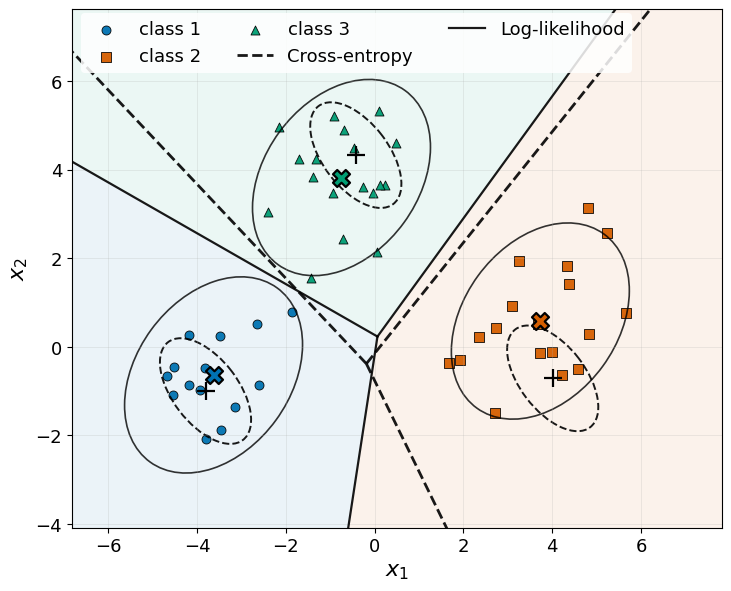

In [3]:
# Gradient descent with cross-entropy on LDA discriminants (shared covariance)
alpha_ce = torch.zeros(C, requires_grad=True)
mu_ce = torch.tensor(mu_mle_cf + 0.2*rng.standard_normal(mu_mle_cf.shape),
                    dtype=torch.float32, requires_grad=True)
L_free_ce = torch.nn.Parameter(torch.zeros(d, d, dtype=torch.float32))
log_diag_ce = torch.nn.Parameter(torch.zeros(d, dtype=torch.float32))

opt_ce = torch.optim.Adam([alpha_ce, mu_ce, L_free_ce, log_diag_ce], lr=5e-2)


def lda_logits(x, alpha, mu, L_free, log_diag):
    # Build shared covariance from Cholesky factors and compute discriminants.
    L = make_cholesky(L_free, log_diag)
    invL = torch.inverse(L)
    Sigma_inv = invL.T @ invL
    pi_log = F.log_softmax(alpha, dim=0)
    w = (Sigma_inv @ mu.T).T
    b = -0.5 * torch.sum(mu @ Sigma_inv * mu, dim=1) + pi_log
    return x @ w.T + b, L


steps = 10000
for t in range(steps):
    logits, L_ce = lda_logits(Xt, alpha_ce, mu_ce, L_free_ce, log_diag_ce)
    loss_ce = F.cross_entropy(logits, yt)
    opt_ce.zero_grad(set_to_none=True)
    loss_ce.backward()
    opt_ce.step()
    if (t + 1) % 500 == 0:
        with torch.no_grad():
            pred = logits.argmax(dim=1)
            acc = (pred == yt).float().mean().item()
        print(f"step {t+1:4d} | ce={loss_ce.item():.4f} | acc={acc:.3f}")

# Extract parameters and compare to closed-form MLE
with torch.no_grad():
    pi_ce = F.softmax(alpha_ce, dim=0).cpu().numpy()
    mu_ce_np = mu_ce.cpu().numpy()
    L_ce_np = make_cholesky(L_free_ce, log_diag_ce).cpu().numpy()
    Sigma_ce = L_ce_np @ L_ce_np.T
    Sigma_inv_ce = np.linalg.inv(Sigma_ce)
    w_ce = (Sigma_inv_ce @ mu_ce_np.T).T
    b_ce = -0.5 * np.sum(mu_ce_np @ Sigma_inv_ce * mu_ce_np, axis=1) + np.log(pi_ce + 1e-12)

Sigma_inv_mle = np.linalg.inv(Sigma_mle_cf)
w_mle = (Sigma_inv_mle @ mu_mle_cf.T).T
b_mle = -0.5 * np.sum(mu_mle_cf @ Sigma_inv_mle * mu_mle_cf, axis=1) + np.log(pi_mle_cf + 1e-12)

pred_ce = (X @ w_ce.T + b_ce).argmax(axis=1)
acc_ce = (pred_ce == ys).mean()
print(f"Cross-entropy LDA training accuracy: {acc_ce:.3f}")


def line_normal_and_offset(w, b, i, j):
    return w[i] - w[j], b[i] - b[j]

def intersect(n1, c1, n2, c2):
    A = np.vstack([n1, n2])
    Cvec = -np.array([c1, c2])
    return np.linalg.solve(A, Cvec)

def ray_extent_from_point(P, d, xlim, ylim):
    ts = []
    if abs(d[0]) > 1e-12:
        ts += [(xlim[0]-P[0])/d[0], (xlim[1]-P[0])/d[0]]
    if abs(d[1]) > 1e-12:
        ts += [(ylim[0]-P[1])/d[1], (ylim[1]-P[1])/d[1]]
    ts_pos = [t for t in ts if t > 0]
    return 0.0 if not ts_pos else min(ts_pos)

# ---- visualization ----
plt.rcParams.update({"font.size": 14, "axes.labelsize": 16, "legend.fontsize": 13,
                    "xtick.labelsize": 13, "ytick.labelsize": 13})
fig, ax = plt.subplots(figsize=(7.2, 5.8), constrained_layout=True)
region_cmap = plt.matplotlib.colors.ListedColormap(OKABE_ITO[:C])

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-2.5, X[:,0].max()+2.5, 400),
                     np.linspace(X[:,1].min()-2.5, X[:,1].max()+2.5, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

# Discriminant grids
logits_ce_grid = grid @ w_ce.T + b_ce
pred_grid_ce = logits_ce_grid.argmax(axis=1).reshape(xx.shape)
logits_mle_grid = grid @ w_mle.T + b_mle
pred_grid_mle = logits_mle_grid.argmax(axis=1).reshape(xx.shape)

ax.contourf(xx, yy, pred_grid_mle, levels=np.arange(C+1)-0.5,
            cmap=region_cmap, alpha=0.08, antialiased=True)

for c in range(C):
    idx = (ys == c)
    ax.scatter(X[idx,0], X[idx,1], s=42, c=colors[c], marker=markers[c],
               edgecolors="black", linewidths=0.6, alpha=0.95, label=f"class {c+1}")

    # Closed-form MLE reference (dashed)
    ax.add_patch(cov_ellipse(mu_mle_cf[c], Sigma_mle_cf, k=2.15,
                             edgecolor="black", facecolor="none", lw=1.2,
                             linestyle="-", alpha=0.8))

    # Cross-entropy fit (solid)
    ax.add_patch(cov_ellipse(mu_ce_np[c], Sigma_ce, k=2.15,
                             edgecolor="black", facecolor="none", lw=1.4,
                             linestyle="--", alpha=0.9))

    # Centers
    ax.scatter(mu_ce_np[c, 0], mu_ce_np[c, 1], s=150, marker="+", c="black",
               edgecolors="black", linewidths=1.6, zorder=7)
    ax.scatter(mu_mle_cf[c, 0], mu_mle_cf[c, 1], s=150, marker="X", c=colors[c],
               edgecolors="black", linewidths=1.6, zorder=7)

# Decision boundaries for CE (solid) and MLE (dashed) clipped at the intersection point
pairs = [(0, 1), (0, 2), (1, 2)]

# Common intersection points
n01_ce, c01_ce = line_normal_and_offset(w_ce, b_ce, 0, 1)
n02_ce, c02_ce = line_normal_and_offset(w_ce, b_ce, 0, 2)
P_ce = intersect(n01_ce, c01_ce, n02_ce, c02_ce)

n01_mle, c01_mle = line_normal_and_offset(w_mle, b_mle, 0, 1)
n02_mle, c02_mle = line_normal_and_offset(w_mle, b_mle, 0, 2)
P_mle = intersect(n01_mle, c01_mle, n02_mle, c02_mle)

ce_label_added = False
mle_label_added = False
for (i, j) in pairs:
    # CE half-line
    n_ce, c_ce = line_normal_and_offset(w_ce, b_ce, i, j)
    d_ce = np.array([-n_ce[1], n_ce[0]], dtype=float)
    d_ce /= np.linalg.norm(d_ce) + 1e-12
    k = ({0,1,2} - {i,j}).pop()
    if (w_ce[k]-w_ce[i]) @ d_ce > 0 or (w_ce[k]-w_ce[j]) @ d_ce > 0:
        d_ce = -d_ce
    tmax_ce = ray_extent_from_point(P_ce, d_ce, (xx.min(), xx.max()), (yy.min(), yy.max()))
    Q_ce = P_ce + tmax_ce * d_ce
    ax.plot([P_ce[0], Q_ce[0]], [P_ce[1], Q_ce[1]], color="black", linewidth=2.0,
            linestyle="--", alpha=0.9, label="Cross-entropy" if not ce_label_added else None)
    ce_label_added = True

    # MLE half-line
    n_mle, c_mle = line_normal_and_offset(w_mle, b_mle, i, j)
    d_mle = np.array([-n_mle[1], n_mle[0]], dtype=float)
    d_mle /= np.linalg.norm(d_mle) + 1e-12
    if (w_mle[k]-w_mle[i]) @ d_mle > 0 or (w_mle[k]-w_mle[j]) @ d_mle > 0:
        d_mle = -d_mle
    tmax_mle = ray_extent_from_point(P_mle, d_mle, (xx.min(), xx.max()), (yy.min(), yy.max()))
    Q_mle = P_mle + tmax_mle * d_mle
    ax.plot([P_mle[0], Q_mle[0]], [P_mle[1], Q_mle[1]], color="black", linewidth=1.6,
            linestyle="-", alpha=0.9, label="Log-likelihood" if not mle_label_added else None)
    mle_label_added = True

#ax.set_title("Cross-entropy training with LDA discriminants")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.legend(frameon=True, framealpha=0.85, facecolor="white", edgecolor="none",
          ncol=3, loc="upper left", bbox_to_anchor=(0.0, 1.01))
ax.axis("equal")
xpad = 2.0
y_pad_bottom = 2.0
y_pad_top = 2.3
xmin, xmax = X[:,0].min()-xpad, X[:,0].max()+xpad
ymin, ymax = X[:,1].min()-y_pad_bottom, X[:,1].max()+y_pad_top
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.grid(True, linewidth=0.4, alpha=0.4)
plt.savefig('lda_cross_entropy.png', dpi=600)


## Logistic-loss training on discriminants
Train LDA discriminants with one-vs-all logistic loss (per-class binary loss)
and compare the learned parameters to the MLE solution.


step  500 | logloss=0.0000 | acc=1.000
step 1000 | logloss=0.0000 | acc=1.000
step 1500 | logloss=0.0000 | acc=1.000
step 2000 | logloss=0.0000 | acc=1.000
step 2500 | logloss=0.0000 | acc=1.000
step 3000 | logloss=0.0000 | acc=1.000
step 3500 | logloss=0.0000 | acc=1.000
step 4000 | logloss=0.0000 | acc=1.000
step 4500 | logloss=0.0000 | acc=1.000
step 5000 | logloss=0.0000 | acc=1.000
step 5500 | logloss=0.0000 | acc=1.000
step 6000 | logloss=0.0000 | acc=1.000
step 6500 | logloss=0.0000 | acc=1.000
step 7000 | logloss=0.0000 | acc=1.000
step 7500 | logloss=0.0000 | acc=1.000
step 8000 | logloss=0.0000 | acc=1.000
step 8500 | logloss=0.0000 | acc=1.000
step 9000 | logloss=0.0000 | acc=1.000
step 9500 | logloss=0.0000 | acc=1.000


/tmp/ipykernel_1059728/1680454557.py:82: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(mu_ll_np[c, 0], mu_ll_np[c, 1], s=150, marker="+", c="black",
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


step 10000 | logloss=0.0000 | acc=1.000
Logistic-loss LDA training accuracy: 1.000


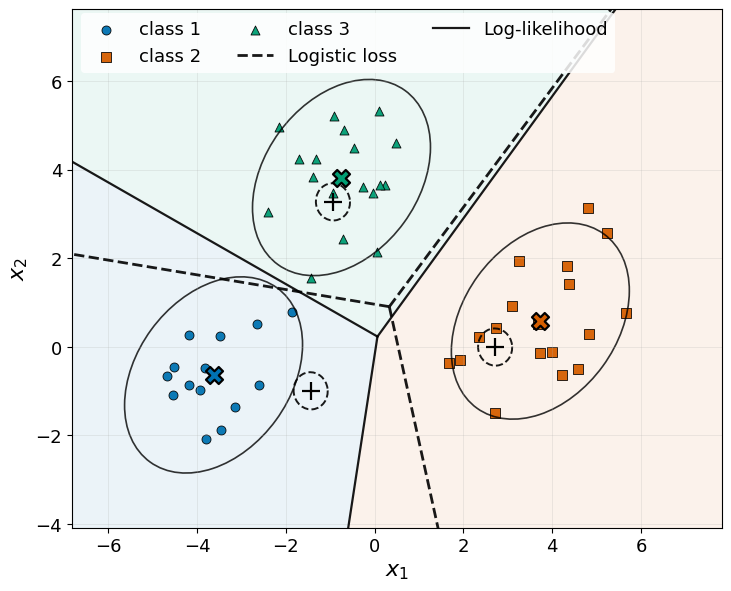

In [4]:
# Gradient descent with logistic loss on LDA discriminants (shared covariance)
import os
import sys

sys.path.insert(0, os.path.abspath(".."))
from lda import logistic_loss

alpha_ll = torch.zeros(C, requires_grad=True)
mu_ll = torch.tensor(mu_mle_cf + 0.2*rng.standard_normal(mu_mle_cf.shape),
                    dtype=torch.float32, requires_grad=True)
L_free_ll = torch.nn.Parameter(torch.zeros(d, d, dtype=torch.float32))
log_diag_ll = torch.nn.Parameter(torch.zeros(d, dtype=torch.float32))

opt_ll = torch.optim.Adam([alpha_ll, mu_ll, L_free_ll, log_diag_ll], lr=5e-2)

steps = 10000
for t in range(steps):
    logits, L_ll = lda_logits(Xt, alpha_ll, mu_ll, L_free_ll, log_diag_ll)
    loss_ll = logistic_loss(logits, yt)
    opt_ll.zero_grad(set_to_none=True)
    loss_ll.backward()
    opt_ll.step()
    if (t + 1) % 500 == 0:
        with torch.no_grad():
            pred = logits.argmax(dim=1)
            acc = (pred == yt).float().mean().item()
        print(f"step {t+1:4d} | logloss={loss_ll.item():.4f} | acc={acc:.3f}")

# Extract parameters and compare to closed-form MLE
with torch.no_grad():
    pi_ll = F.softmax(alpha_ll, dim=0).cpu().numpy()
    mu_ll_np = mu_ll.cpu().numpy()
    L_ll_np = make_cholesky(L_free_ll, log_diag_ll).cpu().numpy()
    Sigma_ll = L_ll_np @ L_ll_np.T
    Sigma_inv_ll = np.linalg.inv(Sigma_ll)
    w_ll = (Sigma_inv_ll @ mu_ll_np.T).T
    b_ll = -0.5 * np.sum(mu_ll_np @ Sigma_inv_ll * mu_ll_np, axis=1) + np.log(pi_ll + 1e-12)

Sigma_inv_mle = np.linalg.inv(Sigma_mle_cf)
w_mle = (Sigma_inv_mle @ mu_mle_cf.T).T
b_mle = -0.5 * np.sum(mu_mle_cf @ Sigma_inv_mle * mu_mle_cf, axis=1) + np.log(pi_mle_cf + 1e-12)

pred_ll = (X @ w_ll.T + b_ll).argmax(axis=1)
acc_ll = (pred_ll == ys).mean()
print(f"Logistic-loss LDA training accuracy: {acc_ll:.3f}")

# ---- visualization ----
plt.rcParams.update({"font.size": 14, "axes.labelsize": 16, "legend.fontsize": 13,
                    "xtick.labelsize": 13, "ytick.labelsize": 13})
fig, ax = plt.subplots(figsize=(7.2, 5.8), constrained_layout=True)
region_cmap = plt.matplotlib.colors.ListedColormap(OKABE_ITO[:C])

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-2.5, X[:,0].max()+2.5, 400),
                     np.linspace(X[:,1].min()-2.5, X[:,1].max()+2.5, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

# Discriminant grids
logits_ll_grid = grid @ w_ll.T + b_ll
pred_grid_ll = logits_ll_grid.argmax(axis=1).reshape(xx.shape)
logits_mle_grid = grid @ w_mle.T + b_mle
pred_grid_mle = logits_mle_grid.argmax(axis=1).reshape(xx.shape)

ax.contourf(xx, yy, pred_grid_mle, levels=np.arange(C+1)-0.5,
            cmap=region_cmap, alpha=0.08, antialiased=True)

for c in range(C):
    idx = (ys == c)
    ax.scatter(X[idx,0], X[idx,1], s=42, c=colors[c], marker=markers[c],
               edgecolors="black", linewidths=0.6, alpha=0.95, label=f"class {c+1}")

    # Closed-form MLE reference (dashed)
    ax.add_patch(cov_ellipse(mu_mle_cf[c], Sigma_mle_cf, k=2.15,
                             edgecolor="black", facecolor="none", lw=1.2,
                             linestyle="-", alpha=0.8))

    # Logistic-loss fit (solid)
    ax.add_patch(cov_ellipse(mu_ll_np[c], Sigma_ll, k=2.15,
                             edgecolor="black", facecolor="none", lw=1.4,
                             linestyle="--", alpha=0.9))

    # Centers
    ax.scatter(mu_ll_np[c, 0], mu_ll_np[c, 1], s=150, marker="+", c="black",
               edgecolors="black", linewidths=1.6, zorder=7)
    ax.scatter(mu_mle_cf[c, 0], mu_mle_cf[c, 1], s=150, marker="X", c=colors[c],
               edgecolors="black", linewidths=1.6, zorder=7)

# Decision boundaries for logistic-loss (solid) and MLE (dashed) clipped at the intersection point
pairs = [(0, 1), (0, 2), (1, 2)]

# Common intersection points
n01_ll, c01_ll = line_normal_and_offset(w_ll, b_ll, 0, 1)
n02_ll, c02_ll = line_normal_and_offset(w_ll, b_ll, 0, 2)
P_ll = intersect(n01_ll, c01_ll, n02_ll, c02_ll)

n01_mle, c01_mle = line_normal_and_offset(w_mle, b_mle, 0, 1)
n02_mle, c02_mle = line_normal_and_offset(w_mle, b_mle, 0, 2)
P_mle = intersect(n01_mle, c01_mle, n02_mle, c02_mle)

ll_label_added = False
mle_label_added = False
for (i, j) in pairs:
    # Logistic-loss half-line
    n_ll, c_ll = line_normal_and_offset(w_ll, b_ll, i, j)
    d_ll = np.array([-n_ll[1], n_ll[0]], dtype=float)
    d_ll /= np.linalg.norm(d_ll) + 1e-12
    k = ({0,1,2} - {i,j}).pop()
    if (w_ll[k]-w_ll[i]) @ d_ll > 0 or (w_ll[k]-w_ll[j]) @ d_ll > 0:
        d_ll = -d_ll
    tmax_ll = ray_extent_from_point(P_ll, d_ll, (xx.min(), xx.max()), (yy.min(), yy.max()))
    Q_ll = P_ll + tmax_ll * d_ll
    ax.plot([P_ll[0], Q_ll[0]], [P_ll[1], Q_ll[1]], color="black", linewidth=2.0,
            linestyle="--", alpha=0.9, label="Logistic loss" if not ll_label_added else None)
    ll_label_added = True

    # MLE half-line
    n_mle, c_mle = line_normal_and_offset(w_mle, b_mle, i, j)
    d_mle = np.array([-n_mle[1], n_mle[0]], dtype=float)
    d_mle /= np.linalg.norm(d_mle) + 1e-12
    if (w_mle[k]-w_mle[i]) @ d_mle > 0 or (w_mle[k]-w_mle[j]) @ d_mle > 0:
        d_mle = -d_mle
    tmax_mle = ray_extent_from_point(P_mle, d_mle, (xx.min(), xx.max()), (yy.min(), yy.max()))
    Q_mle = P_mle + tmax_mle * d_mle
    ax.plot([P_mle[0], Q_mle[0]], [P_mle[1], Q_mle[1]], color="black", linewidth=1.6,
            linestyle="-", alpha=0.9, label="Log-likelihood" if not mle_label_added else None)
    mle_label_added = True

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.legend(frameon=True, framealpha=0.85, facecolor="white", edgecolor="none",
          ncol=3, loc="upper left", bbox_to_anchor=(0.0, 1.01))
ax.axis("equal")
xpad = 2.0
y_pad_bottom = 2.0
y_pad_top = 2.3
xmin, xmax = X[:,0].min()-xpad, X[:,0].max()+xpad
ymin, ymax = X[:,1].min()-y_pad_bottom, X[:,1].max()+y_pad_top
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.grid(True, linewidth=0.4, alpha=0.4)
plt.savefig('lda_logistic_loss.png', dpi=600)
